<a href="https://colab.research.google.com/github/Eshachatterjee01/data_science_all/blob/main/K_Means_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/DataScience_and_MachineLearning_Intellipaat/Datasets/Mall_Customers.csv")

In [ ]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
df.shape

(200, 5)

In [ ]:
#we will drop CustomerId column because with this unique id we cant create any clusters.we will drop it.

df.drop(columns=['CustomerID'])

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [ ]:
df.head(2)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81


In [ ]:
#if you want to drop 'CustomerID' permanently then you have to mention inplace = true

df.drop(columns=['CustomerID'],inplace=True)

In [ ]:
df.head(2) #now CustomerID gone

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81


In [ ]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#we can do label encding in gender column to convert string to numeric but we will do another thing

#label Encoding code
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df['Gender'] = le.fit_transform(df['Gender'])



In [ ]:
#we will do another process to conver not label Encoding..you can do label encoding also

df['Gender'] = df['Gender'].map({'Male' : 0, 'Female' : 1})
#df['Gender']= df['Gender'].replace({'Male': 0, 'Female': 1}) this will also work

In [ ]:
df.head(5) #you can check its converted into numeric without label encoding

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


How data is showing in 4D you can see that using plotly

In [ ]:
# import plotly.express as px
# fig = px.scatter_3d(x)

Kmeans algo says that if you give information  to kmeans algo in array format then kmeans will be able to work much faster compare to dataframe format.

because:-  

Mathematical operations → K-Means needs to compute distances, means, and matrix operations. NumPy arrays are optimized for fast linear algebra, while DataFrames are higher-level wrappers.  

Efficiency → NumPy arrays are more memory- and computation-efficient than DataFrames, which carry extra metadata (column names, indexes, dtypes).

So we will convert dataframe into array format..values will convert df dataframe into array format

In [ ]:
X = df.values

In [ ]:
X #its converted in to array

array([[  0,  19,  15,  39],
       [  0,  21,  15,  81],
       [  1,  20,  16,   6],
       [  1,  23,  16,  77],
       [  1,  31,  17,  40],
       [  1,  22,  17,  76],
       [  1,  35,  18,   6],
       [  1,  23,  18,  94],
       [  0,  64,  19,   3],
       [  1,  30,  19,  72],
       [  0,  67,  19,  14],
       [  1,  35,  19,  99],
       [  1,  58,  20,  15],
       [  1,  24,  20,  77],
       [  0,  37,  20,  13],
       [  0,  22,  20,  79],
       [  1,  35,  21,  35],
       [  0,  20,  21,  66],
       [  0,  52,  23,  29],
       [  1,  35,  23,  98],
       [  0,  35,  24,  35],
       [  0,  25,  24,  73],
       [  1,  46,  25,   5],
       [  0,  31,  25,  73],
       [  1,  54,  28,  14],
       [  0,  29,  28,  82],
       [  1,  45,  28,  32],
       [  0,  35,  28,  61],
       [  1,  40,  29,  31],
       [  1,  23,  29,  87],
       [  0,  60,  30,   4],
       [  1,  21,  30,  73],
       [  0,  53,  33,   4],
       [  0,  18,  33,  92],
       [  1,  

In [ ]:
X[0]

array([ 0, 19, 15, 39])

Process of Calculating WCSS value for identifying the optimal k value.

Kmeans++ means kmeans++ verion of kmeans algorithm.
k-means++ gives smarter starting points, leading to faster and more accurate clustering.

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
wcss = []

for k in range(1,5):
  kmeans = KMeans(n_clusters=k, init='k-means++')
  kmeans.fit(X)
  print(kmeans.inertia_) # inertia or wcss ,It is the sum of squared distances of each data point to its nearest cluster centroid (also called Within-Cluster Sum of Squares, WCSS).
  wcss.append(kmeans.inertia_)

308862.06000000006
221136.4418859649
143391.59236035674
105299.98742210327


In [ ]:
wcss  #we can see WCSS1>WCSS2>Wcss3 so on .num of cluster increasing and inertia decreasing

[308862.06000000006, 221136.4418859649, 143391.59236035674, 105299.98742210327]

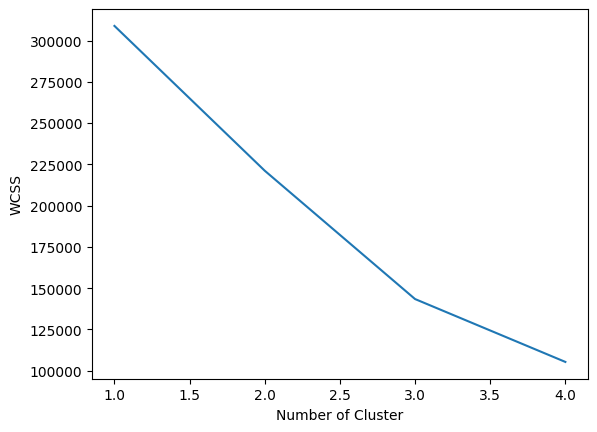

In [ ]:
#plotting the k value(number of cluster here we took 1 to 5) and their coressponding wcss value
plt.plot(range(1,5),wcss)  #plt.plot makes a line plot and in x position we took range 1 to 5 and in y we took wcss
plt.xlabel('Number of Cluster')
plt.ylabel('WCSS')
plt.show()

fit_predict(X) = fit + predict in one step ✅

fit(X) → runs K-Means on the dataset X (finds centroids).

predict(X) → assigns each data point in X to the nearest centroid (returns cluster labels).

fit_predict(X) → does both: it trains the model and returns the cluster labels in a single call.

we can write kmeans.fit_predict(X)

In [ ]:
#now from the graph we got the kvalue =3 (that is elbow point).now again we will apply kmeans algorithm on the X

km = KMeans(n_clusters=3,init='k-means++')
# km.fit(X)
# km.predict(X)
km.fit_predict(X) #we got 1 2 0 these are cluster number.so first row is belongs to cluster 1 2d also cluster 1 like that.


array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2], dtype=int32)

In [ ]:
Y = km.predict(X)

In [ ]:
#wo sare rows jo cluster number 0 me blong karta hai
X[Y == 0]

array([[  1,  20,  16,   6],
       [  1,  35,  18,   6],
       [  0,  64,  19,   3],
       [  0,  67,  19,  14],
       [  1,  58,  20,  15],
       [  0,  37,  20,  13],
       [  0,  52,  23,  29],
       [  1,  46,  25,   5],
       [  1,  54,  28,  14],
       [  1,  45,  28,  32],
       [  1,  40,  29,  31],
       [  0,  60,  30,   4],
       [  0,  53,  33,   4],
       [  1,  49,  33,  14],
       [  1,  42,  34,  17],
       [  1,  36,  37,  26],
       [  1,  65,  38,  35],
       [  0,  48,  39,  36],
       [  1,  49,  39,  28],
       [  1,  50,  40,  55],
       [  1,  29,  40,  42],
       [  1,  31,  40,  42],
       [  1,  49,  42,  52],
       [  0,  59,  43,  60],
       [  1,  50,  43,  45],
       [  0,  47,  43,  41],
       [  1,  51,  44,  50],
       [  0,  69,  44,  46],
       [  0,  53,  46,  46],
       [  0,  70,  46,  56],
       [  1,  67,  47,  52],
       [  1,  54,  47,  59],
       [  0,  63,  48,  51],
       [  1,  43,  48,  50],
       [  1,  

In [ ]:
#agar cluster number 0 ka 1st index ka column extract karna hai tab
X[Y == 0,1]

array([20, 35, 64, 67, 58, 37, 52, 46, 54, 45, 40, 60, 53, 49, 42, 36, 65,
       48, 49, 50, 29, 31, 49, 59, 50, 47, 51, 69, 53, 70, 67, 54, 63, 43,
       68, 32, 70, 47, 60, 60, 59, 26, 45, 40, 23, 49, 57, 38, 67, 46, 48,
       55, 22, 34, 50, 68, 18, 48, 40, 32, 24, 47, 27, 48, 20, 23, 49, 67,
       26, 49, 21, 66, 54, 68, 66, 65, 19, 38, 19, 18, 19, 63, 49, 51, 50,
       27, 38, 40, 23, 43, 59, 47, 25, 20, 44, 19, 57, 28, 25, 48, 34, 43,
       44, 47, 37, 34, 56, 19, 50, 42, 36, 40, 36, 52, 58, 59, 37, 46, 41,
       54, 41, 34, 33, 47, 45, 32])

In [ ]:
#agar cluster number 2 ka 0th(gender wala) index ka column extract karna hai tab
X[Y == 2,0]

array([0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0])

Y become our output column,we have to attach into out dataframe. but right now Y is in array format so we need to convert it into dataframe first then we will concatinate with main dataframe (df)

In [ ]:
#convert it into dataframe
output = pd.DataFrame(Y, columns= ['Cluster Number'])

In [ ]:
output

,Cluster Number
0,1
1,1
2,0
3,1
4,1
...,...
195,2
196,0
197,2
198,0


In [ ]:
final_df = pd.concat([df,output], axis=1)

In [ ]:
final_df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster Number
0,0,19,15,39,1
1,0,21,15,81,1
2,1,20,16,6,0
3,1,23,16,77,1
4,1,31,17,40,1
...,...,...,...,...,...
195,1,35,120,79,2
196,1,45,126,28,0
197,0,32,126,74,2
198,0,32,137,18,0


Summary:-  Now its become a classsification dataset.we can now apply decision tree,random forest,Logistic Regression in this dataset..  
just devide this data into X and Y like however yo does in supervised algorithm and then check the accuracy which algorithm gives highest accuracy and all..


Now plot the data into 3d plot

In [ ]:
#to plot multidimension we use plotly
import plotly.express as px

In [ ]:
final_df.columns

Index(['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)',
       'Cluster Number'],
      dtype='object')

In [ ]:
fig = px.scatter_3d(data_frame=final_df, x = 'Gender' , y = 'Age' , z = 'Annual Income (k$)' , color = 'Cluster Number' , hover_name= 'Spending Score (1-100)', title = '3d scatter plot for Mall Customer')
fig.show()

Trying with cluster number = 4

In [ ]:
km = KMeans(n_clusters=4,init='k-means++')
km.fit_predict(X)
Y = km.predict(X)
output = pd.DataFrame(Y, columns= ['Cluster Number'])
final_for_4_df = pd.concat([df,output], axis=1)

In [ ]:
final_for_4_df

,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster Number
0,0,19,15,39,0
1,0,21,15,81,0
2,1,20,16,6,2
3,1,23,16,77,0
4,1,31,17,40,0
...,...,...,...,...,...
195,1,35,120,79,1
196,1,45,126,28,3
197,0,32,126,74,1
198,0,32,137,18,3


In [ ]:
fig = px.scatter_3d(data_frame=final_for_4_df, x = 'Gender' , y = 'Age' , z = 'Annual Income (k$)' , color = 'Cluster Number' , hover_name= 'Spending Score (1-100)', title = '3d scatter plot for Mall Customer')
fig.show()

# **Kmeans algorithm practicle by Adhya Mam**

step 1-choose the number of clusters -k values-wcss

step-2 intialize rando points as centroids

step-3 assign clustering based on distance

step-4--- update the centroids based on its mean

step-5 repaet values until the centroid doesnt changes much

Player 🏏 – Name of the cricketer and country/team they represented.

Span 📅 – The years between the player’s debut and last match.

Mat 🎯 – Total number of One Day International (ODI) matches played.

Inns 🚪 – Number of innings the player batted in.

NO 🙅‍♂️ – Times the player remained not out at the end of an innings.

Runs 🏃‍♂️ – Total runs scored in all ODI matches.

HS 🔝 – Highest score in a single innings (* means not out).

Ave 📊 – Batting average: total runs ÷ (innings - not outs).

BF 🕒 – Balls faced across all innings.

SR ⚡ – Strike rate: runs scored per 100 balls.

100 💯 – Number of centuries (100+ runs in an innings).

50 🌓 – Number of half-centuries (50–99 runs in an innings).

0 🥶 – Number of times the player got out for a duck (zero runs).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
cricket = pd.read_csv("/content/drive/MyDrive/DataScience_and_MachineLearning_Intellipaat/Datasets/circket.csv")

UnicodeDecodeError: 'utf-8' codec can't decode byte 0xa0 in position 64: invalid start byte

In [ ]:
#utf-8' codec can't decode byte 0xa0 in position 64: invalid start byte
#this error coming because something has written in the dataset which is not reading by the dataset we will use encoding = 'latin'

cricket = pd.read_csv("/content/drive/MyDrive/DataScience_and_MachineLearning_Intellipaat/Datasets/circket.csv" , encoding= "latin")

In [ ]:
cricket

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15
2,RT Ponting (AUS/ICC),1995-2012,375,365,39,13704,164,42.03,17046,80.39,30,82,20
3,ST Jayasuriya (Asia/SL),1989-2011,445,433,18,13430,189,32.36,14725,91.20,28,68,34
4,DPMD Jayawardene (Asia/SL),1998-2015,448,418,39,12650,144,33.37,16020,78.96,19,77,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),1975-1991,128,127,13,5134,133*,45.03,7908,64.92,11,31,3
75,Misbah-ul-Haq (PAK),2002-2015,162,149,31,5122,96*,43.40,6945,73.75,0,42,6
76,PD Collingwood (ENG),2001-2011,197,181,37,5092,120*,35.36,6614,76.98,5,26,7
77,A Symonds (AUS),1998-2009,198,161,33,5088,156,39.75,5504,92.44,6,30,15


In [ ]:
cricket.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  79 non-null     object 
 1   Span    79 non-null     object 
 2   Mat     79 non-null     int64  
 3   Inns    79 non-null     int64  
 4   NO      79 non-null     int64  
 5   Runs    79 non-null     int64  
 6   HS      79 non-null     object 
 7   Ave     79 non-null     float64
 8   BF      79 non-null     int64  
 9   SR      79 non-null     float64
 10  100     79 non-null     int64  
 11  50      79 non-null     int64  
 12  0       79 non-null     int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 8.2+ KB


.str.split("-", expand=True)

.str.split("-") splits each string in the "Span" column wherever it finds a "-".
Example: "10-20" → ["10", "20"]

expand=True turns the result into a DataFrame with separate columns, instead of a list inside one cell.

In [ ]:
#span is also object because in span "-" this sign is there
#here span giving us how many years experience they have
#now we will create two new comuns because with span column object data we cant work.we have to access the year of experience and store them into the new column
#based on the "-" we will do string split here before "-" we will use that as start after "-" we will take as end column
cricket[['Start_Playing', 'End_Playing']] = cricket['Span'].str.split('-', expand=True)


In [ ]:
cricket.head(2) #Now you can see span clumn splited into two column

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Start_Playing,End_Playing
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,1989,2012
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015


In [ ]:
cricket['Start_Playing'].dtype #it is in object type

dtype('O')

In [ ]:
#we have to change object to int
cricket['Start_Playing'] = cricket['Start_Playing'].astype(int)
cricket['End_Playing'] = cricket['End_Playing'].astype(int)

In [ ]:
cricket['Start_Playing'].dtype

dtype('int64')

In [ ]:
#Now we can extract, how many years of experience each player have and make another experience column and calculate and store that value
cricket['Experience'] = cricket['End_Playing'] - cricket['Start_Playing']

In [ ]:
cricket.head(2)

,Player,Span,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Start_Playing,End_Playing,Experience
0,SR Tendulkar (INDIA),1989-2012,463,452,41,18426,200*,44.83,21367,86.23,49,96,20,1989,2012,23
1,KC Sangakkara (Asia/ICC/SL),2000-2015,404,380,41,14234,169,41.98,18048,78.86,25,93,15,2000,2015,15


In [ ]:
#now we can  remove span start and end column
cricket.drop(columns=['Start_Playing','End_Playing','Span'] , axis=1 , inplace = True)

In [ ]:
#now we get the proper input data
cricket.head(2)


,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Experience
0,SR Tendulkar (INDIA),463,452,41,18426,200*,44.83,21367,86.23,49,96,20,23
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,169,41.98,18048,78.86,25,93,15,15


In [ ]:
#now you can see in HS column there is * that mean not out 200* means highest score 200 not out but machine cannot understand the *
# i can only string replace the * with blank


cricket['HS'] = cricket['HS'].str.replace('*',"")

In [ ]:
cricket['HS'].dtype

dtype('O')

In [ ]:
#we replace the * but now we need to change the datatype object to int
cricket['HS'] = cricket['HS'].astype(int)

In [ ]:
#checknull
#check duplicate
#check outliers
cricket.isnull().sum().sum()

np.int64(0)

In [ ]:
cricket.duplicated().sum()

np.int64(0)

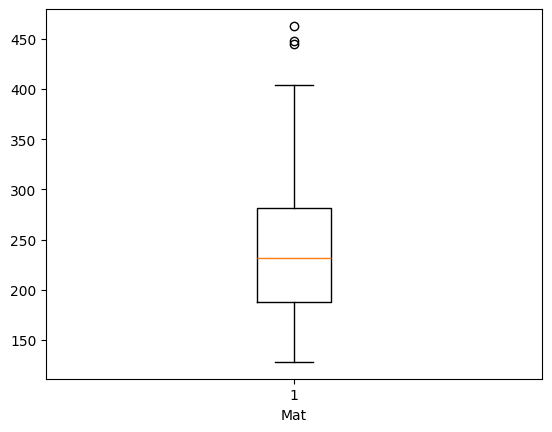

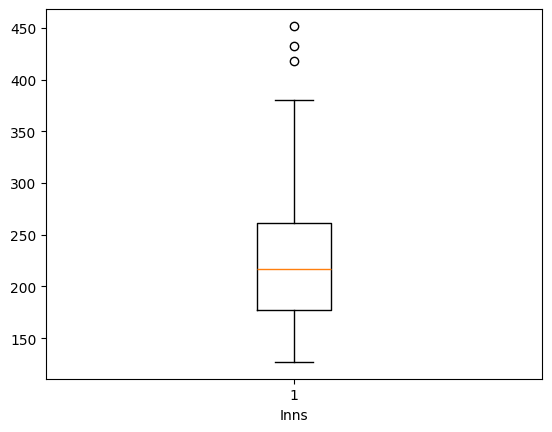

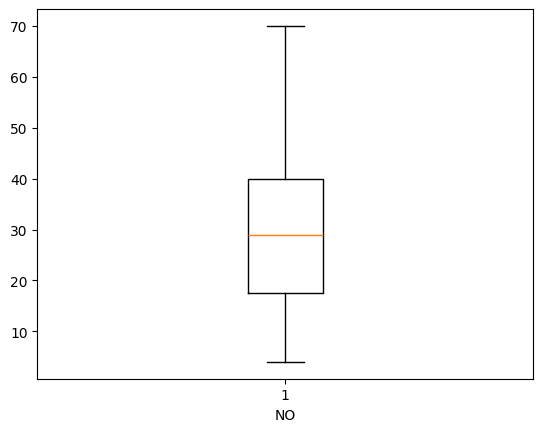

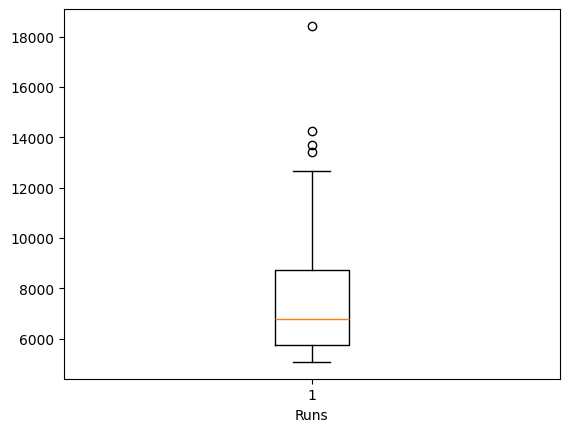

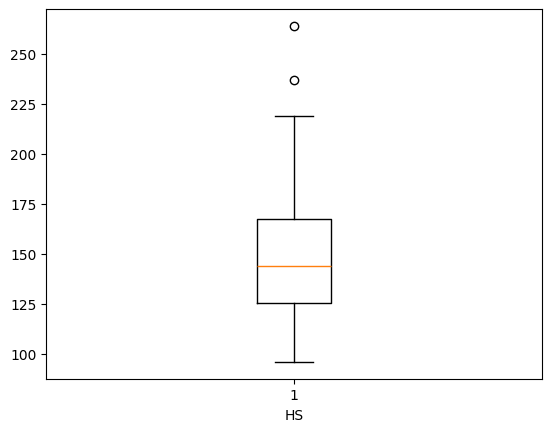

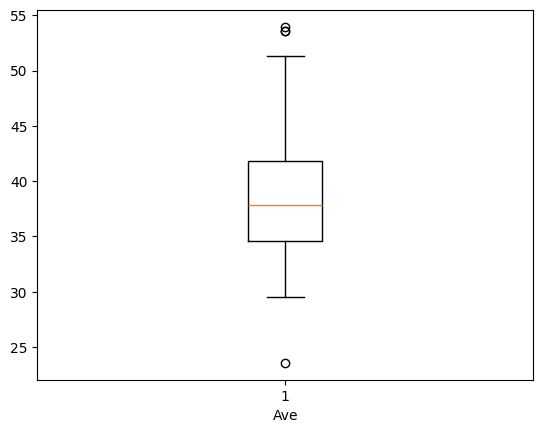

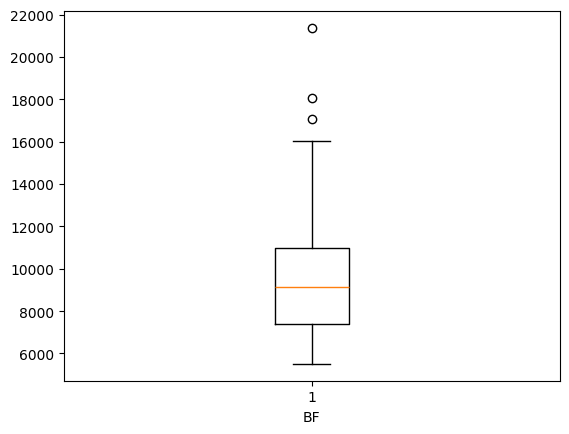

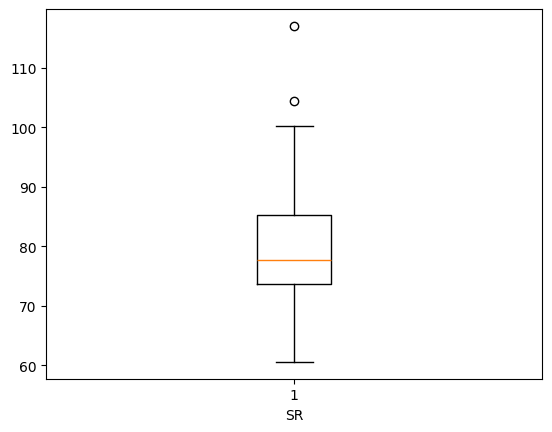

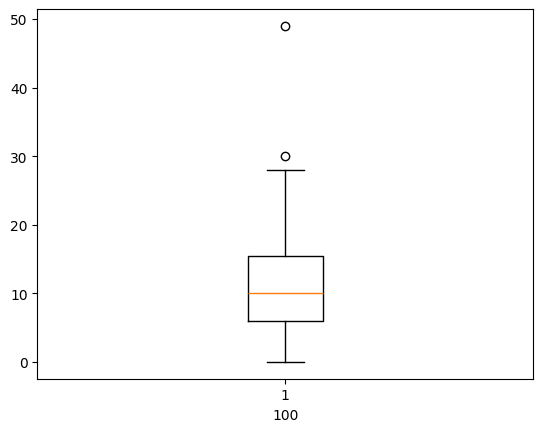

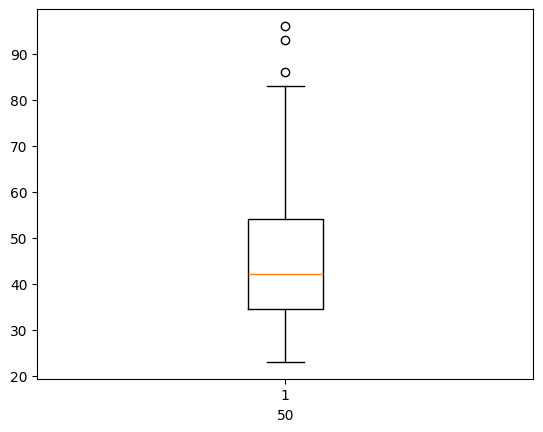

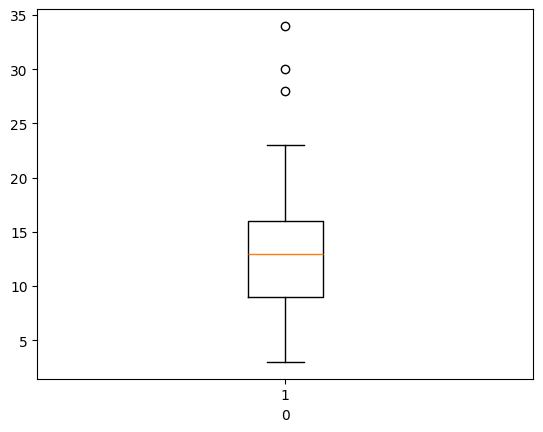

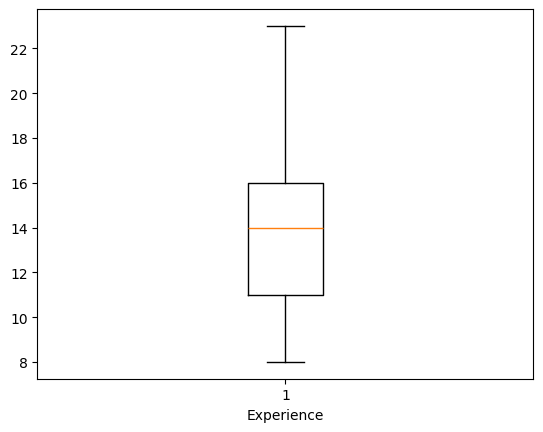

In [ ]:
#checking outlier
for i in cricket.columns:
    if cricket[i].dtype != "object":
        plt.boxplot(cricket[i])
        plt.xlabel(i)
        plt.show()

when we are applying stabdard scaller concept we are changing the data in such a way that all their mean value will be 0 and standard deviation will be 1 #this is called feature scaling also #It standardizes the features by removing the mean and scaling to unit variance. Result: After applying StandardScaler:

The mean of each feature becomes 0

The standard deviation becomes 1



In [ ]:
# we dont need player information for now that y we are not removing it but we are just copying the whole dataset and
#if we change in the copied dataset
#it will not make any impact on original dataset

cricket_copy = cricket.copy()

In [ ]:
cricket_copy

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Experience
0,SR Tendulkar (INDIA),463,452,41,18426,200,44.83,21367,86.23,49,96,20,23
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,169,41.98,18048,78.86,25,93,15,15
2,RT Ponting (AUS/ICC),375,365,39,13704,164,42.03,17046,80.39,30,82,20,17
3,ST Jayasuriya (Asia/SL),445,433,18,13430,189,32.36,14725,91.20,28,68,34,22
4,DPMD Jayawardene (Asia/SL),448,418,39,12650,144,33.37,16020,78.96,19,77,28,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,CG Greenidge (WI),128,127,13,5134,133,45.03,7908,64.92,11,31,3,16
75,Misbah-ul-Haq (PAK),162,149,31,5122,96,43.40,6945,73.75,0,42,6,13
76,PD Collingwood (ENG),197,181,37,5092,120,35.36,6614,76.98,5,26,7,10
77,A Symonds (AUS),198,161,33,5088,156,39.75,5504,92.44,6,30,15,11


In [ ]:
#now we will remove the playercolumn from the cricket_copy dataframe
cricket_copy.drop(columns=['Player'] , axis = 1, inplace=True)

In [ ]:
#now we will do standardization
from sklearn.preprocessing import StandardScaler

In [ ]:
se = StandardScaler()
cricket_scaled = se.fit_transform(cricket_copy)

In [ ]:
cricket_scaled #its become array format

array([[ 2.95528204e+00,  3.16933340e+00,  7.64962749e-01,
         4.26232808e+00,  1.63244320e+00,  1.07229395e+00,
         3.68121424e+00,  7.03151526e-01,  4.65672622e+00,
         3.05005720e+00,  1.14583653e+00,  2.81278702e+00],
       [ 2.15517925e+00,  2.13891509e+00,  7.64962749e-01,
         2.60911662e+00,  6.35223595e-01,  5.87724608e-01,
         2.63538469e+00, -4.41394951e-02,  1.67188751e+00,
         2.86541772e+00,  2.96670622e-01,  3.80938324e-01],
       [ 1.76190839e+00,  1.92424461e+00,  6.25396797e-01,
         2.40009894e+00,  4.74381724e-01,  5.96225824e-01,
         2.31965067e+00,  1.10996904e-01,  2.29372891e+00,
         2.18840630e+00,  1.14583653e+00,  9.88900497e-01],
       [ 2.71118288e+00,  2.89741746e+00, -8.40045698e-01,
         2.29204075e+00,  1.27859108e+00, -1.04790945e+00,
         1.58829472e+00,  1.20709133e+00,  2.04499235e+00,
         1.32675540e+00,  3.52350108e+00,  2.50880593e+00],
       [ 2.75186607e+00,  2.68274698e+00,  6.2539679

In [ ]:
#we will change that arrays format into the dataframe format
cricket_scaled = pd.DataFrame(cricket_scaled, columns = cricket_copy.columns)

In [ ]:
cricket_scaled

,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Experience
0,2.955282,3.169333,0.764963,4.262328,1.632443,1.072294,3.681214,0.703152,4.656726,3.050057,1.145837,2.812787
1,2.155179,2.138915,0.764963,2.609117,0.635224,0.587725,2.635385,-0.044139,1.671888,2.865418,0.296671,0.380938
2,1.761908,1.924245,0.625397,2.400099,0.474382,0.596226,2.319651,0.110997,2.293729,2.188406,1.145837,0.988900
3,2.711183,2.897417,-0.840046,2.292041,1.278591,-1.047909,1.588295,1.207091,2.044992,1.326755,3.523501,2.508806
4,2.751866,2.682747,0.625397,1.984430,-0.168986,-0.876185,1.996354,-0.034000,0.925678,1.880674,2.504502,0.988900
...,...,...,...,...,...,...,...,...,...,...,...,...
74,-1.587674,-1.481860,-1.188961,-0.979677,-0.522838,1.106299,-0.559768,-1.457604,-0.069268,-0.950465,-1.741328,0.684919
75,-1.126598,-1.167010,0.067133,-0.984410,-1.713068,0.829159,-0.863213,-0.562275,-1.437319,-0.273453,-1.231828,-0.227024
76,-0.651961,-0.709047,0.485831,-0.996241,-0.941027,-0.537836,-0.967512,-0.234765,-0.815478,-1.258197,-1.061995,-1.138967
77,-0.638400,-0.995274,0.206699,-0.997819,0.217035,0.208570,-1.317278,1.332823,-0.691110,-1.012011,0.296671,-0.834986


now we can check that data standarddized or not by checking per columns mean and std, if mean= 0 and std = 1 then its standardized  
if you apply the standdard scaler it will convert the data in such a way that every column having mean value 0 and std 1

it is scaling the data that is why it is called feature scaling

In [ ]:
#now we will check the each columns mean 0 and std =1 or not

cricket_scaled['Runs'].mean() #e^-16 it maes 0.16zero then126 so it is equavalent to 0 only

np.float64(1.2648110407122037e-16)

In [ ]:
cricket_scaled['Runs'].std()

1.0063898413738652

**How to choose the number of clusters**

In [ ]:
from sklearn.cluster import KMeans

ssd sum of square deviations  
inertia_ will calculate how good the datapoints in the dataset are clustered,wheather they are tightly clustered or loosely clustered,it will check that


In [ ]:
#for experiment we are taking kvalue from my choice
k_value = [2,3,4,5,6,7]

ssd = []
for k in k_value:
  km = KMeans(n_clusters= k ,max_iter=150, random_state=42)
  km.fit(cricket_scaled)
  km.inertia_
  ssd.append(km.inertia_)


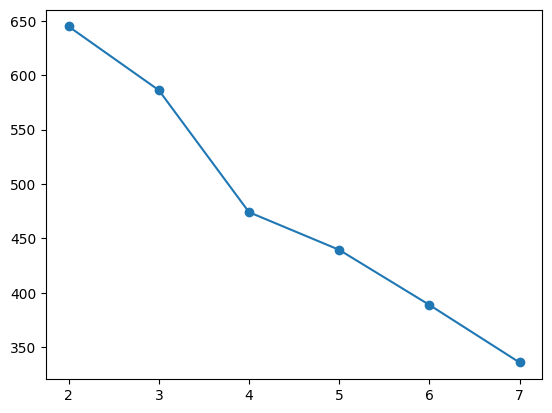

In [ ]:
plt.plot(k_value,ssd,marker="o")

In [ ]:
#my optimal choice of k_value would be 4 because from 4 point it becoming a straignt flat line
#dont try to make so many clusters so try to choose as small as like 4 not 9 10 then that many clusters it will creates

ksmodel = KMeans(n_clusters= 4, max_iter=120, random_state=32)

In [ ]:
ksmodel.fit(cricket_scaled)

KMeans(max_iter=120, n_clusters=4, random_state=32)

In [ ]:
#now check the label that our particular data has given by using inbuilt keyword labels_
#you will get the cluster number given by the matching.. which datapoint belongs to which cluster that cluster number.

print(ksmodel.labels_)

[2 2 2 2 2 2 2 2 2 1 1 1 1 1 1 3 1 1 1 1 1 1 1 1 3 3 1 1 1 1 1 1 1 1 3 1 0
 0 0 3 0 1 3 1 0 0 0 0 0 3 1 0 0 0 0 0 0 0 0 3 0 0 0 3 0 3 0 0 0 0 0 0 0 0
 0 0 0 0 0]


In [ ]:
#now we are adding this labels to out main dataset df
cricket['ClusterId'] = ksmodel.labels_

In [ ]:
cricket.head(5)

,Player,Mat,Inns,NO,Runs,HS,Ave,BF,SR,100,50,0,Experience,ClusterId
0,SR Tendulkar (INDIA),463,452,41,18426,200,44.83,21367,86.23,49,96,20,23,2
1,KC Sangakkara (Asia/ICC/SL),404,380,41,14234,169,41.98,18048,78.86,25,93,15,15,2
2,RT Ponting (AUS/ICC),375,365,39,13704,164,42.03,17046,80.39,30,82,20,17,2
3,ST Jayasuriya (Asia/SL),445,433,18,13430,189,32.36,14725,91.20,28,68,34,22,2
4,DPMD Jayawardene (Asia/SL),448,418,39,12650,144,33.37,16020,78.96,19,77,28,17,2


**now ploting it into 2d**  
In 2d plot we cannot understand the cluster in proper way..

<Axes: xlabel='Runs', ylabel='Ave'>

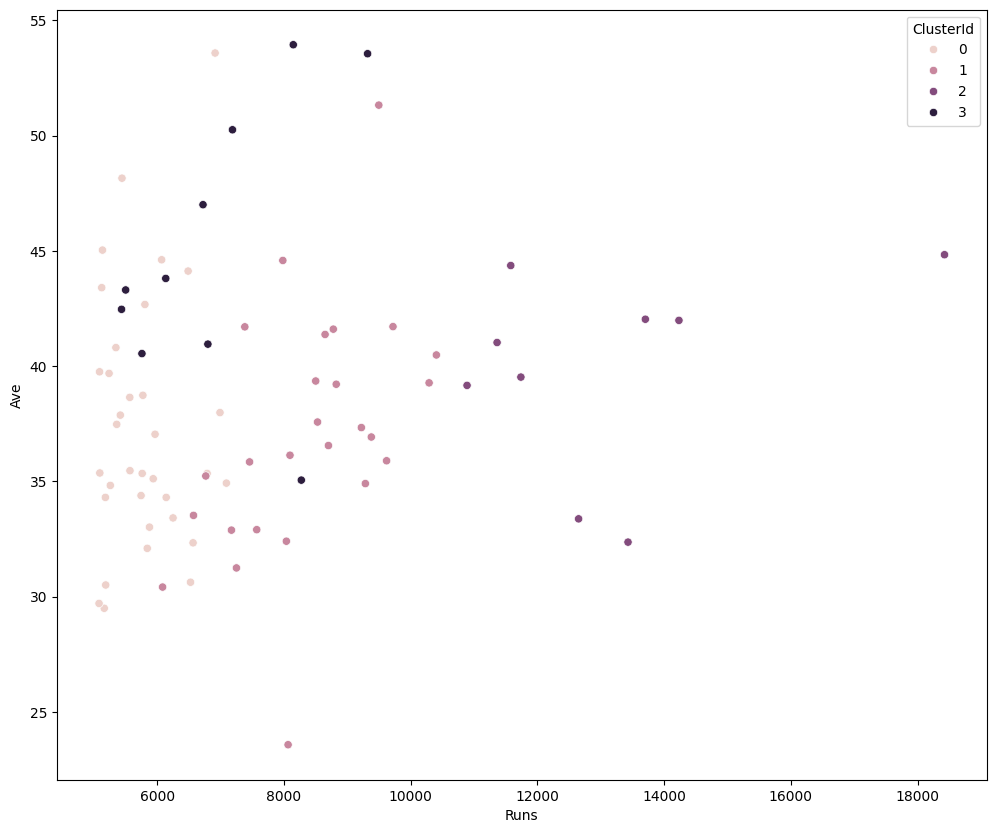

In [ ]:
import seaborn as sns

plt.figure(figsize=(12,10))
sns.scatterplot(data = cricket,x= 'Runs', y = 'Ave', hue= 'ClusterId')

**Now we will create this in 3d format**  
you can take any 3 column

In [ ]:
import plotly.express as px

In [ ]:
cricket.columns

Index(['Player', 'Mat', 'Inns', 'NO', 'Runs', 'HS', 'Ave', 'BF', 'SR', '100',
       '50', '0', 'Experience', 'ClusterId'],
      dtype='object')

In [ ]:
fig = px.scatter_3d(data_frame=cricket, x= 'Runs', y = 'Ave', z = 'SR', color="ClusterId", hover_name="Player", title= "3D scatter plot for Cricket dataset")
fig.show()

In [ ]:
fig = px.scatter_3d(data_frame=cricket, x= 'Runs', y = 'Ave', z = 'SR', color="ClusterId", hover_name="Player", title= "3D scatter plot for Cricket dataset")
fig.update_layout(scene = dict(xaxis_title = "Runs",yaxis_title ='Average',zaxis_title= 'strikr rate'),width = 800,height = 600)
fig.show()